
# phagemorph: classifying phage TEM images based on morphotype

This notebook does five things:

1. Loads and cleans the metadata CSV.
2. Pads each TEM image to a square and resizes it to **265 × 265** pixels.
3. Trains a **CNN classifier** for the three morphotypes: **sipho, podo, myo** using an **80:20 train:test split**.
4. Plots **one-vs-rest ROC curves** for each class and provides a function to predict the morphotype of a new image.
5. Visualises what the trained CNN has learned using filter grids, layer-wise activation heatmaps, and dense-layer activations.

The notebook is written to work with the files you supplied:

- `Phagebase_Images_cropped_partial/`
- `Phagebase_table_cropped_partial.csv`

Because the dataset is small, model performance can vary between runs. You can improve stability by adding more labelled images, using stronger augmentation, or training for more epochs.


In [1]:

import os
import re
import shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: cpu


In [2]:

# Update these paths if your files live elsewhere
IMAGE_DIR = Path('/Users/vijinimallawaarachchi/Documents/Data/Phagebase/Phagebase_Images_cropped_partial')
CSV_PATH = Path('/Users/vijinimallawaarachchi/Documents/Data/Phagebase/Phagebase_table_cropped_partial.csv')

WORK_DIR = Path('phagemorph_project')
PROCESSED_DIR = WORK_DIR / 'processed_265'
MODEL_PATH = WORK_DIR / 'tem_morphotype_cnn.pt'

WORK_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('Image directory exists:', IMAGE_DIR.exists())
print('CSV exists:', CSV_PATH.exists())


Image directory exists: True
CSV exists: True


## 1) Load and standardise the metadata

In [3]:

metadata = pd.read_csv(CSV_PATH).copy()

# Standardise column names
metadata.columns = (
    metadata.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

# Standardise morphotype labels
morphotype_map = {
    'siphophage': 'sipho',
    'sipho': 'sipho',
    'podophage': 'podo',
    'podo': 'podo',
    'myophage': 'myo',
    'myo': 'myo'
}
metadata['morphotype_clean'] = (
    metadata['morphotype']
    .astype(str)
    .str.strip()
    .str.lower()
    .map(morphotype_map)
)

def stem_from_text(value):
    text = str(value).strip()
    if not text or text.lower() == 'nan':
        return ''
    text = text.split(' (', 1)[0].strip()
    return Path(text).stem

def normalize_stem(value):
    stem = str(value).strip()
    if not stem or stem.lower() == 'nan':
        return ''
    stem = re.sub(r'(?i) copy(?: \d+)?$', '', stem).strip()
    stem = re.sub(r'_\d+$', '', stem)
    return stem.strip()

# Standardise filename keys used to look up labels in the CSV
metadata['download_name'] = metadata['download_name'].astype(str).str.strip()
metadata['file_stem'] = metadata['download_name'].map(stem_from_text)
metadata['name_stem'] = metadata['name'].astype(str).str.strip()
metadata['image_stem'] = metadata['image'].map(stem_from_text)

lookup_frames = []
for source_name, column_name, priority in [
    ('download_name', 'file_stem', 0),
    ('image', 'image_stem', 1),
    ('name', 'name_stem', 2),
]:
    lookup = metadata[[column_name, 'morphotype_clean']].copy()
    lookup = lookup.rename(columns={column_name: 'lookup_stem'})
    lookup['lookup_source'] = source_name
    lookup['lookup_priority'] = priority
    lookup_frames.append(lookup)

metadata_lookup = pd.concat(lookup_frames, ignore_index=True)
metadata_lookup['lookup_stem'] = metadata_lookup['lookup_stem'].astype(str).str.strip()
metadata_lookup = metadata_lookup[
    metadata_lookup['lookup_stem'].ne('') & metadata_lookup['lookup_stem'].ne('nan')
].copy()

ambiguous_lookup = metadata_lookup.groupby('lookup_stem')['morphotype_clean'].nunique()
ambiguous_lookup = ambiguous_lookup[ambiguous_lookup > 1].index
metadata_lookup = metadata_lookup[~metadata_lookup['lookup_stem'].isin(ambiguous_lookup)].copy()
metadata_lookup = (
    metadata_lookup
    .sort_values(['lookup_stem', 'lookup_priority'])
    .drop_duplicates(subset=['lookup_stem'], keep='first')
    .reset_index(drop=True)
)

metadata_lookup_normalized = metadata_lookup.copy()
metadata_lookup_normalized['lookup_stem_normalized'] = metadata_lookup_normalized['lookup_stem'].map(normalize_stem)
metadata_lookup_normalized = metadata_lookup_normalized[
    metadata_lookup_normalized['lookup_stem_normalized'].ne('')
].copy()

ambiguous_lookup_normalized = metadata_lookup_normalized.groupby('lookup_stem_normalized')['morphotype_clean'].nunique()
ambiguous_lookup_normalized = ambiguous_lookup_normalized[ambiguous_lookup_normalized > 1].index
metadata_lookup_normalized = (
    metadata_lookup_normalized[~metadata_lookup_normalized['lookup_stem_normalized'].isin(ambiguous_lookup_normalized)]
    .sort_values(['lookup_stem_normalized', 'lookup_priority'])
    .drop_duplicates(subset=['lookup_stem_normalized'], keep='first')
    .reset_index(drop=True)
)

# Convert numeric columns where possible
for col in ['capsid_diameter_nm', 'length_head_to_tail', 'body_length']:
    if col in metadata.columns:
        metadata[col] = pd.to_numeric(metadata[col], errors='coerce')

metadata.head()


,name,image,image_templink,morphotype,phage_host,comments,attribution,date_added,capsid_diameter_nm,length_head_to_tail,body_length,download_name,morphotype_clean,file_stem,name_stem,image_stem
0,1A,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Siphophage,Bacillus sphaericus,Scale bars represent 50 nm. Image generously d...,https://www.phage.ulaval.ca/?pageDemandee=phag...,"May 23, 2024",NaN,NaN,NaN,1A.png,sipho,1A,1A,image
1,2D05,2D05.png (https://v5.airtableusercontent.com/v...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,Aeromonas hydrophila,Scale bar represents 100 nm,https://www.mdpi.com/1999-4915/11/7/615,"May 18, 2024",NaN,NaN,NaN,2D05.png,myo,2D05,2D05,2D05
2,2L372X,Screenshot 2024-05-05 at 3.55.12 PM.png (https...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,Aeromonas hydrophila,Scale bar represents 100nm,https://www.mdpi.com/1999-4915/11/7/615,"May 6, 2024",NaN,NaN,NaN,2L372X_2.png,myo,2L372X_2,2L372X,Screenshot 2024-05-05 at 3.55.12 PM
3,3A,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Siphophage,Staphylococcus aureus,Scale bars represent 50 nm. Image generously d...,https://www.phage.ulaval.ca/?pageDemandee=phag...,"May 23, 2024",NaN,NaN,NaN,3A.png,sipho,3A,3A,image
4,3M,image.png (https://v5.airtableusercontent.com/...,https://v5.airtableusercontent.com/v3/u/30/30/...,Myophage,Serratia marcescens,Scale bars represent 50 nm. Image generously d...,https://www.phage.ulaval.ca/?pageDemandee=phag...,"May 23, 2024",NaN,NaN,NaN,3M.png,myo,3M,3M,image


In [4]:

print('Metadata shape:', metadata.shape)
print('Morphotype counts from CSV:')
print(metadata['morphotype_clean'].value_counts(dropna=False))
print('Missing morphotype labels in CSV:', metadata['morphotype_clean'].isna().sum())
print('Duplicate download-name stems in CSV:', metadata['file_stem'].duplicated().sum())
print('Exact lookup stems available:', metadata_lookup['lookup_stem'].nunique())
print('Ambiguous exact lookup stems dropped:', len(ambiguous_lookup))
print('Normalized lookup stems available:', metadata_lookup_normalized['lookup_stem_normalized'].nunique())
print('Ambiguous normalized lookup stems dropped:', len(ambiguous_lookup_normalized))


Metadata shape: (503, 16)
Morphotype counts from CSV:
morphotype_clean
sipho    186
myo      165
podo     142
NaN       10
Name: count, dtype: int64
Missing morphotype labels in CSV: 10
Duplicate download-name stems in CSV: 0
Exact lookup stems available: 580
Ambiguous exact lookup stems dropped: 3
Normalized lookup stems available: 470
Ambiguous normalized lookup stems dropped: 1


## 2) Index images from the flat image folder

In [5]:

image_rows = []
valid_ext = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp'}

for img_path in sorted(IMAGE_DIR.iterdir()):
    if not img_path.is_file() or img_path.name.startswith('.') or img_path.suffix.lower() not in valid_ext:
        continue
    try:
        with Image.open(img_path) as im:
            width, height = im.size
            mode = im.mode
        image_rows.append({
            'image_path': str(img_path),
            'filename': img_path.name,
            'file_stem': img_path.stem,
            'file_stem_normalized': normalize_stem(img_path.stem),
            'width': width,
            'height': height,
            'mode': mode,
            'extension': img_path.suffix.lower()
        })
    except Exception as e:
        print(f'Skipping unreadable image {img_path.name}: {e}')

images_df = pd.DataFrame(image_rows)
images_df.head()


,image_path,filename,file_stem,file_stem_normalized,width,height,mode,extension
0,/Users/vijinimallawaarachchi/Documents/Data/Ph...,05F.png,05F,05F,215,213,RGBA,.png
1,/Users/vijinimallawaarachchi/Documents/Data/Ph...,113.png,113,113,131,140,RGBA,.png
2,/Users/vijinimallawaarachchi/Documents/Data/Ph...,121.png,121,121,418,427,RGBA,.png
3,/Users/vijinimallawaarachchi/Documents/Data/Ph...,1214 Lindberg.png,1214 Lindberg,1214 Lindberg,298,483,RGBA,.png
4,/Users/vijinimallawaarachchi/Documents/Data/Ph...,1672.png,1672,1672,302,475,RGBA,.png


In [6]:

print('Image count:', len(images_df))
print('Image extensions:')
print(images_df['extension'].value_counts())

exact_images_only = set(images_df['file_stem']) - set(metadata_lookup['lookup_stem'])
exact_csv_only = set(metadata_lookup['lookup_stem']) - set(images_df['file_stem'])
normalized_images_only = (
    set(images_df['file_stem_normalized']) - set(metadata_lookup_normalized['lookup_stem_normalized'])
)

print('Images without exact CSV match:', len(exact_images_only))
print('Sample images without exact CSV match:', sorted(exact_images_only)[:20])
print('CSV lookup stems without exact image match:', len(exact_csv_only))
print('Images without normalized CSV match:', len(normalized_images_only))
print('Sample images without normalized CSV match:', sorted(normalized_images_only)[:20])


Image count: 504
Image extensions:
extension
.png     487
.jpg      11
.jpeg      6
Name: count, dtype: int64
Images without exact CSV match: 6
Sample images without exact CSV match: ['DCp1 copy', 'G', 'K', 'phiCcoIBB35_4', 'phiLdb_2', 'phiPA1-3_2']
CSV lookup stems without exact image match: 82
Images without normalized CSV match: 1
Sample images without normalized CSV match: ['pEp_SNUABM']


## 3) Merge image index with metadata and resolve labels

In [7]:

exact_lookup = metadata_lookup[['lookup_stem', 'morphotype_clean', 'lookup_source']].rename(
    columns={
        'lookup_stem': 'lookup_stem_exact',
        'morphotype_clean': 'morphotype_clean_exact',
        'lookup_source': 'lookup_source_exact'
    }
)
normalized_lookup = metadata_lookup_normalized[['lookup_stem_normalized', 'morphotype_clean', 'lookup_source']].rename(
    columns={
        'morphotype_clean': 'morphotype_clean_normalized',
        'lookup_source': 'lookup_source_normalized'
    }
)

dataset_df = images_df.merge(
    exact_lookup,
    left_on='file_stem',
    right_on='lookup_stem_exact',
    how='left'
)
dataset_df = dataset_df.merge(
    normalized_lookup,
    left_on='file_stem_normalized',
    right_on='lookup_stem_normalized',
    how='left'
)

# Prefer an exact CSV stem match, then fall back to a normalized match for duplicate-like suffixes.
dataset_df['morphotype_clean'] = dataset_df['morphotype_clean_exact'].fillna(dataset_df['morphotype_clean_normalized'])
dataset_df['label'] = dataset_df['morphotype_clean']
dataset_df['label_source'] = np.select(
    [
        dataset_df['morphotype_clean_exact'].notna(),
        dataset_df['morphotype_clean_normalized'].notna(),
    ],
    [
        'csv_exact',
        'csv_normalized',
    ],
    default='unmatched'
)

# Keep only rows with a valid final label from the CSV-derived lookups.
valid_labels = ['sipho', 'podo', 'myo']
dataset_df = dataset_df[dataset_df['label'].isin(valid_labels)].copy()

# Remove accidental duplicates by final filename if any.
dataset_df = dataset_df.drop_duplicates(subset=['filename']).reset_index(drop=True)

print('Final dataset size:', len(dataset_df))
print(dataset_df['label'].value_counts())
print('Label sources:')
print(dataset_df['label_source'].value_counts())

dataset_df[['filename', 'file_stem', 'file_stem_normalized', 'morphotype_clean', 'label', 'label_source', 'width', 'height']].head(10)


Final dataset size: 495
label
sipho    189
myo      164
podo     142
Name: count, dtype: int64
Label sources:
label_source
csv_exact         489
csv_normalized      6
Name: count, dtype: int64


,filename,file_stem,file_stem_normalized,morphotype_clean,label,label_source,width,height
0,05F.png,05F,05F,myo,myo,csv_exact,215,213
1,113.png,113,113,myo,myo,csv_exact,131,140
2,121.png,121,121,sipho,sipho,csv_exact,418,427
3,1214 Lindberg.png,1214 Lindberg,1214 Lindberg,myo,myo,csv_exact,298,483
4,1672.png,1672,1672,myo,myo,csv_exact,302,475
5,187.png,187,187,sipho,sipho,csv_exact,210,529
6,1A.png,1A,1A,sipho,sipho,csv_exact,372,542
7,2638A.png,2638A,2638A,sipho,sipho,csv_exact,420,545
8,2811.png,2811,2811,sipho,sipho,csv_exact,145,129
9,290F.png,290F,290F,sipho,sipho,csv_exact,270,490


## 4) Pre-process images: pad to square, resize to 265 × 265, and save cleaned copies

In [8]:

TARGET_SIZE = (265, 265)


def pad_to_square_and_resize(image: Image.Image, size=(265, 265), fill_color=255):
    """
    Convert image to grayscale, pad to square, then resize.
    fill_color=255 gives a white background which is usually sensible for TEM figures.
    """
    image = image.convert('L')
    width, height = image.size
    side = max(width, height)

    pad_left = (side - width) // 2
    pad_top = (side - height) // 2
    pad_right = side - width - pad_left
    pad_bottom = side - height - pad_top

    image = ImageOps.expand(
        image,
        border=(pad_left, pad_top, pad_right, pad_bottom),
        fill=fill_color
    )
    image = image.resize(size, Image.Resampling.LANCZOS)
    return image


# Clean output directory first so reruns stay deterministic
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

processed_rows = []
for row in dataset_df.itertuples(index=False):
    out_dir = PROCESSED_DIR / row.label
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'{Path(row.filename).stem}.png'

    with Image.open(row.image_path) as im:
        processed_im = pad_to_square_and_resize(im, size=TARGET_SIZE)
        processed_im.save(out_path)

    processed_rows.append({
        'processed_path': str(out_path),
        'label': row.label,
        'filename': row.filename,
        'file_stem': row.file_stem
    })

processed_df = pd.DataFrame(processed_rows)
print(processed_df.head())
print('Processed image counts:')
print(processed_df['label'].value_counts())


                                      processed_path  label  \
0       phagemorph_project/processed_265/myo/05F.png    myo   
1       phagemorph_project/processed_265/myo/113.png    myo   
2     phagemorph_project/processed_265/sipho/121.png  sipho   
3  phagemorph_project/processed_265/myo/1214 Lind...    myo   
4      phagemorph_project/processed_265/myo/1672.png    myo   

            filename      file_stem  
0            05F.png            05F  
1            113.png            113  
2            121.png            121  
3  1214 Lindberg.png  1214 Lindberg  
4           1672.png           1672  
Processed image counts:
label
sipho    189
myo      164
podo     142
Name: count, dtype: int64


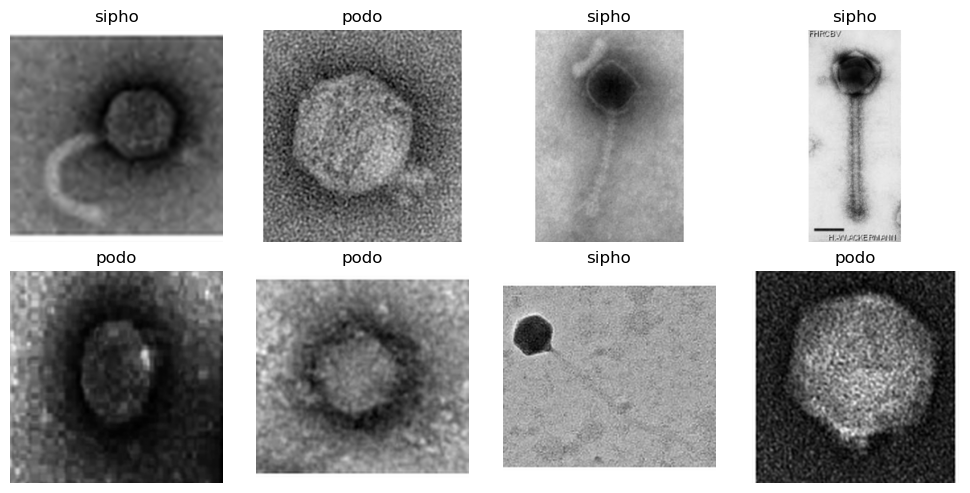

In [9]:

# Quick visual sanity check
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, row in zip(axes.ravel(), processed_df.sample(min(8, len(processed_df)), random_state=SEED).itertuples(index=False)):
    img = Image.open(row.processed_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(row.label)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 5) Train:test split (80:20, stratified)

In [10]:

train_df, test_df = train_test_split(
    processed_df,
    test_size=0.20,
    random_state=SEED,
    stratify=processed_df['label']
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print('Train size:', len(train_df))
print('Test size:', len(test_df))
print('Train label counts:')
print(train_df['label'].value_counts())
print('Test label counts:')
print(test_df['label'].value_counts())


Train size: 396
Test size: 99
Train label counts:
label
sipho    151
myo      131
podo     114
Name: count, dtype: int64
Test label counts:
label
sipho    38
myo      33
podo     28
Name: count, dtype: int64


## 6) PyTorch dataset and dataloaders

In [11]:

class_names = ['sipho', 'podo', 'myo']
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}


def pil_to_tensor(img: Image.Image):
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)  # (1, H, W)
    return torch.tensor(arr, dtype=torch.float32)


class TEMDataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.dataframe)

    def _augment(self, img):
        # Light augmentation for a small dataset
        if np.random.rand() < 0.5:
            img = ImageOps.mirror(img)
        if np.random.rand() < 0.5:
            img = ImageOps.flip(img)
        if np.random.rand() < 0.5:
            angle = np.random.uniform(-15, 15)
            img = img.rotate(angle, fillcolor=255)
        return img

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img = Image.open(row['processed_path']).convert('L')
        if self.augment:
            img = self._augment(img)
        x = pil_to_tensor(img)
        y = class_to_idx[row['label']]
        return x, y


BATCH_SIZE = 8

train_ds = TEMDataset(train_df, augment=True)
test_ds = TEMDataset(test_df, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


## 7) Define the CNN model

In [12]:

class PhageMorphotypeCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = PhageMorphotypeCNN(num_classes=len(class_names)).to(DEVICE)
print(model)


PhageMorphotypeCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05, momentum=0

## 8) Train the CNN

In [13]:

EPOCHS = 50
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * x_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total


for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)
        preds = logits.argmax(dim=1)
        running_correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    train_loss = running_loss / total
    train_acc = running_correct / total
    test_loss, test_acc = evaluate(model, test_loader, criterion)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f'Epoch {epoch:02d}/{EPOCHS} | '
          f'train_loss={train_loss:.4f} train_acc={train_acc:.3f} | '
          f'test_loss={test_loss:.4f} test_acc={test_acc:.3f}')

# Save trained weights and class mapping
checkpoint = {
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'target_size': TARGET_SIZE,
}
torch.save(checkpoint, MODEL_PATH)
print(f'Saved model to: {MODEL_PATH}')


Epoch 01/50 | train_loss=5.2096 train_acc=0.417 | test_loss=2.7640 test_acc=0.283
Epoch 02/50 | train_loss=1.5265 train_acc=0.442 | test_loss=0.9204 test_acc=0.525
Epoch 03/50 | train_loss=0.9343 train_acc=0.513 | test_loss=0.8733 test_acc=0.586
Epoch 04/50 | train_loss=0.9873 train_acc=0.477 | test_loss=0.8636 test_acc=0.657
Epoch 05/50 | train_loss=0.8902 train_acc=0.535 | test_loss=0.8443 test_acc=0.616
Epoch 06/50 | train_loss=0.9237 train_acc=0.540 | test_loss=0.8624 test_acc=0.586
Epoch 07/50 | train_loss=0.8938 train_acc=0.545 | test_loss=0.8566 test_acc=0.505
Epoch 08/50 | train_loss=0.9004 train_acc=0.556 | test_loss=0.8253 test_acc=0.626
Epoch 09/50 | train_loss=0.8816 train_acc=0.551 | test_loss=0.8271 test_acc=0.616
Epoch 10/50 | train_loss=0.8472 train_acc=0.551 | test_loss=0.8967 test_acc=0.616
Epoch 11/50 | train_loss=0.8178 train_acc=0.581 | test_loss=0.7750 test_acc=0.545
Epoch 12/50 | train_loss=0.8301 train_acc=0.556 | test_loss=0.7787 test_acc=0.616
Epoch 13/50 | tr

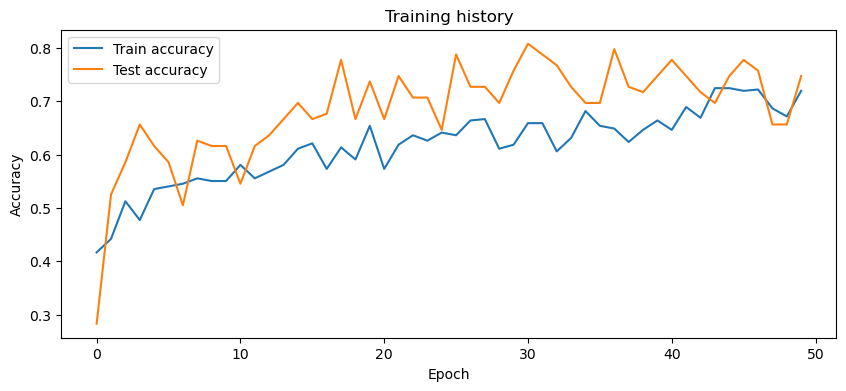

In [14]:

plt.figure(figsize=(10, 4))
plt.plot(history['train_acc'], label='Train accuracy')
plt.plot(history['test_acc'], label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training history')
plt.legend()
plt.show()


## 9) Evaluate model performance and plot ROC curves for each class

In [15]:

model.eval()
all_probs = []
all_true = []
all_pred = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(DEVICE)
        logits = model(x_batch)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

        all_probs.append(probs)
        all_true.append(y_batch.numpy())
        all_pred.append(preds)

all_probs = np.vstack(all_probs)
all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

print(classification_report(all_true, all_pred, target_names=class_names, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(all_true, all_pred))


              precision    recall  f1-score   support

       sipho       0.75      0.71      0.73        38
        podo       0.83      0.86      0.84        28
         myo       0.68      0.70      0.69        33

    accuracy                           0.75        99
   macro avg       0.75      0.75      0.75        99
weighted avg       0.75      0.75      0.75        99

Confusion matrix:
[[27  2  9]
 [ 2 24  2]
 [ 7  3 23]]


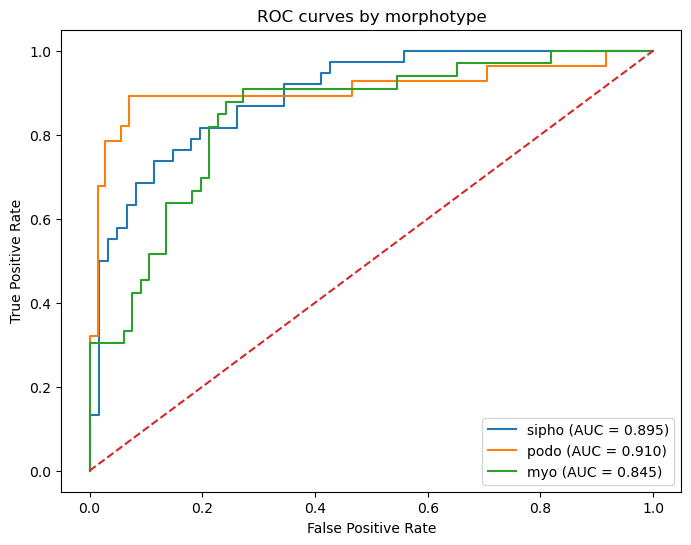

In [16]:

# One-vs-rest ROC curves
true_binarized = label_binarize(all_true, classes=np.arange(len(class_names)))

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(true_binarized[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves by morphotype')
plt.legend(loc='lower right')
plt.show()


## 10) Visualise what the CNN learned in each layer

The plots below use a few representative test images to show how the CNN transforms each TEM image across its learned layers:

- **First-layer filters** show the edge and texture detectors learned directly from the pixels.
- **Activation overlays** show where each convolutional layer is responding most strongly.
- **Dense-layer activations** show which abstract features are most active before the final classifier.

This is not a proof of causality, but it gives a practical view of what each learned stage is focusing on.


In [17]:
LEARNED_LAYER_MODULES = [
    ('conv1', model.features[0]),
    ('conv2', model.features[4]),
    ('conv3', model.features[8]),
    ('conv4', model.features[12]),
    ('dense_embedding', model.classifier[2]),
    ('logits', model.classifier[4]),
]
CONV_LAYER_NAMES = ['conv1', 'conv2', 'conv3', 'conv4']


def preprocess_for_explanation(image_path, size=TARGET_SIZE):
    with Image.open(image_path) as im:
        processed = pad_to_square_and_resize(im, size=size)
    return processed


def capture_learned_layer_outputs(model, image_tensor, device=DEVICE):
    outputs = {}
    hooks = []

    for name, module in LEARNED_LAYER_MODULES:
        hooks.append(
            module.register_forward_hook(
                lambda module, inputs, output, layer_name=name: outputs.setdefault(layer_name, output.detach().cpu())
            )
        )

    model.eval()
    with torch.no_grad():
        logits = model(image_tensor.unsqueeze(0).to(device))
        probs = torch.softmax(logits, dim=1).cpu().squeeze(0).numpy()

    for hook in hooks:
        hook.remove()

    return outputs, probs


def activation_energy_map(layer_output):
    layer_output = layer_output.squeeze(0)
    return layer_output.abs().mean(dim=0).numpy()


def plot_first_layer_filters(model, max_filters=None, n_cols=4):
    filters = model.features[0].weight.detach().cpu().squeeze(1)
    if max_filters is not None:
        filters = filters[:max_filters]

    n_filters = filters.shape[0]
    n_rows = int(np.ceil(n_filters / n_cols))
    vlim = np.abs(filters.numpy()).max()

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.2 * n_rows))
    axes = np.atleast_1d(axes).ravel()

    for ax, filt, idx in zip(axes, filters, range(n_filters)):
        ax.imshow(filt, cmap='coolwarm', vmin=-vlim, vmax=vlim)
        ax.set_title(f'Filter {idx}')
        ax.axis('off')

    for ax in axes[n_filters:]:
        ax.axis('off')

    fig.suptitle('Learned first-layer convolution filters', fontsize=14)
    plt.tight_layout()
    plt.show()


def score_dataframe(model, dataframe, batch_size=16, device=DEVICE):
    dataset = TEMDataset(dataframe, augment=False)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scored_batches = []
    start = 0

    model.eval()
    with torch.no_grad():
        for x_batch, y_batch in loader:
            logits = model(x_batch.to(device))
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = probs.argmax(axis=1)
            confs = probs.max(axis=1)

            batch_df = dataframe.iloc[start:start + len(y_batch)].copy()
            batch_df['true_idx'] = y_batch.numpy()
            batch_df['pred_idx'] = preds
            batch_df['pred_label'] = [class_names[i] for i in preds]
            batch_df['confidence'] = confs
            for idx, class_name in enumerate(class_names):
                batch_df[f'prob_{class_name}'] = probs[:, idx]

            scored_batches.append(batch_df)
            start += len(y_batch)

    return pd.concat(scored_batches, ignore_index=True)


def select_representative_examples(scored_df, n_correct_examples=2):
    selections = []
    rank_labels = {
        1: 'highest-confidence correct example',
        2: 'second highest-confidence correct example',
    }

    for class_name in class_names:
        class_df = scored_df[scored_df['label'] == class_name].copy()
        correct_df = (
            class_df[class_df['pred_label'] == class_name]
            .sort_values('confidence', ascending=False)
            .reset_index(drop=True)
        )

        if not correct_df.empty:
            for rank, (_, picked_row) in enumerate(correct_df.head(n_correct_examples).iterrows(), start=1):
                picked = picked_row.copy()
                picked['selection_rank'] = rank
                picked['selection_note'] = rank_labels.get(rank, f'#{rank} highest-confidence correct example')
                selections.append(picked)
        else:
            prob_col = f'prob_{class_name}'
            picked = class_df.sort_values(prob_col, ascending=False).iloc[0]
            picked = picked.copy()
            picked['selection_rank'] = np.nan
            picked['selection_note'] = 'fallback: no correct prediction for this class'
            selections.append(picked)

    return pd.DataFrame(selections).reset_index(drop=True)


def plot_layerwise_explanation(image_path, expected_label=None, title_prefix='', model_override=None, class_names_local=None):
    model_to_use = model if model_override is None else model_override
    class_names_local = class_names if class_names_local is None else class_names_local

    processed = preprocess_for_explanation(image_path)
    image_tensor = pil_to_tensor(processed)
    layer_outputs, probs = capture_learned_layer_outputs(model_to_use, image_tensor)
    pred_idx = int(np.argmax(probs))
    pred_label = class_names_local[pred_idx]

    fig, axes = plt.subplots(1, 7, figsize=(24, 4.2))

    axes[0].imshow(processed, cmap='gray')
    axes[0].set_title('Input image')
    axes[0].axis('off')

    for col_idx, layer_name in enumerate(CONV_LAYER_NAMES, start=1):
        heatmap = activation_energy_map(layer_outputs[layer_name])
        axes[col_idx].imshow(processed, cmap='gray')
        axes[col_idx].imshow(heatmap, cmap='inferno', alpha=0.55)
        shape = tuple(layer_outputs[layer_name].shape[1:])
        axes[col_idx].set_title(f'{layer_name}\noutput={shape}')
        axes[col_idx].axis('off')

    dense_values = layer_outputs['dense_embedding'].squeeze(0).numpy()
    top_dense_idx = np.argsort(dense_values)[-10:]
    axes[5].barh(range(len(top_dense_idx)), dense_values[top_dense_idx], color='tab:blue')
    axes[5].set_yticks(range(len(top_dense_idx)))
    axes[5].set_yticklabels(top_dense_idx)
    axes[5].set_title('Dense embedding\n(top 10 units)')
    axes[5].set_xlabel('Activation')

    preferred_display_order = ['sipho', 'myo', 'podo']
    display_labels = [label for label in preferred_display_order if label in class_names_local]
    display_labels += [label for label in class_names_local if label not in display_labels]
    label_to_prob = dict(zip(class_names_local, probs))
    display_probs = [label_to_prob[label] for label in display_labels]
    axes[6].barh(display_labels, display_probs, color='tab:green')
    axes[6].invert_yaxis()
    axes[6].set_xlim(0, 1)
    axes[6].set_title(f'Class probabilities\npred={pred_label}')
    axes[6].set_xlabel('Probability')

    expected_text = expected_label if expected_label is not None else 'unknown'
    prefix = f'{title_prefix} | ' if title_prefix else ''
    fig.suptitle(
        f'{prefix}expected={expected_text}, predicted={pred_label}, confidence={probs[pred_idx]:.3f}',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()


def explain_prediction_layers(image_path, expected_label=None, title_prefix='', model_override=None, class_names_local=None):
    plot_layerwise_explanation(
        image_path=image_path,
        expected_label=expected_label,
        title_prefix=title_prefix,
        model_override=model_override,
        class_names_local=class_names_local,
    )


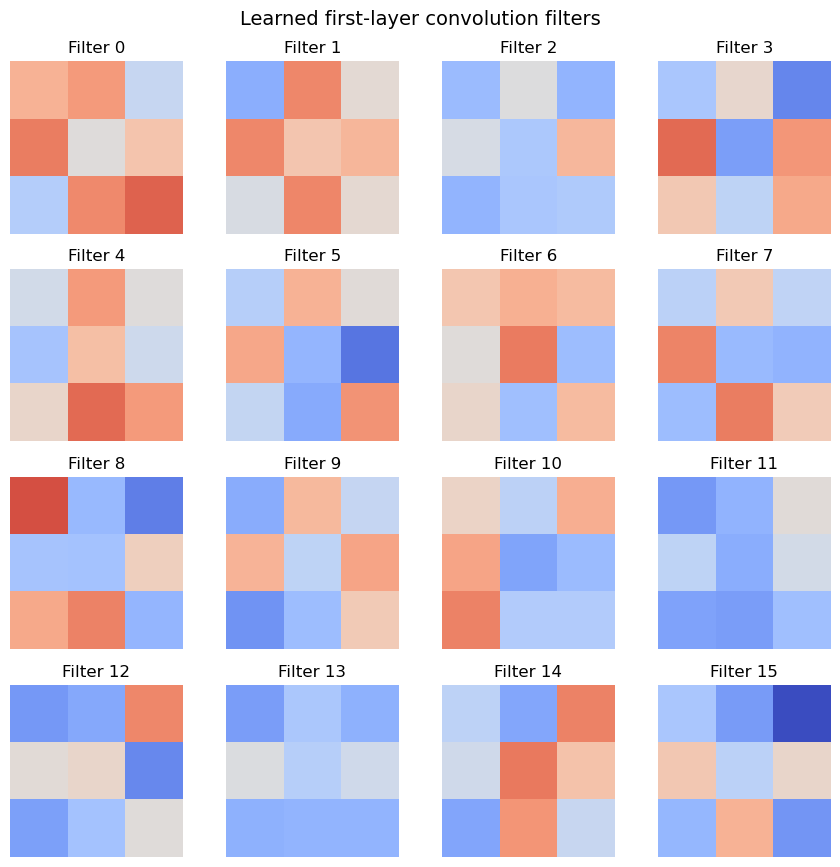

,true_label,pred_label,confidence,selection_rank,selection_note,filename
0,sipho,sipho,0.990820,1,highest-confidence correct example,3A.png
1,sipho,sipho,0.989172,2,second highest-confidence correct example,D3112.png
2,podo,podo,1.000000,1,highest-confidence correct example,Bc01_3.png
3,podo,podo,1.000000,2,second highest-confidence correct example,Phage R.png
4,myo,myo,0.839426,1,highest-confidence correct example,KM16.png
5,myo,myo,0.797583,2,second highest-confidence correct example,PAK_P1.png


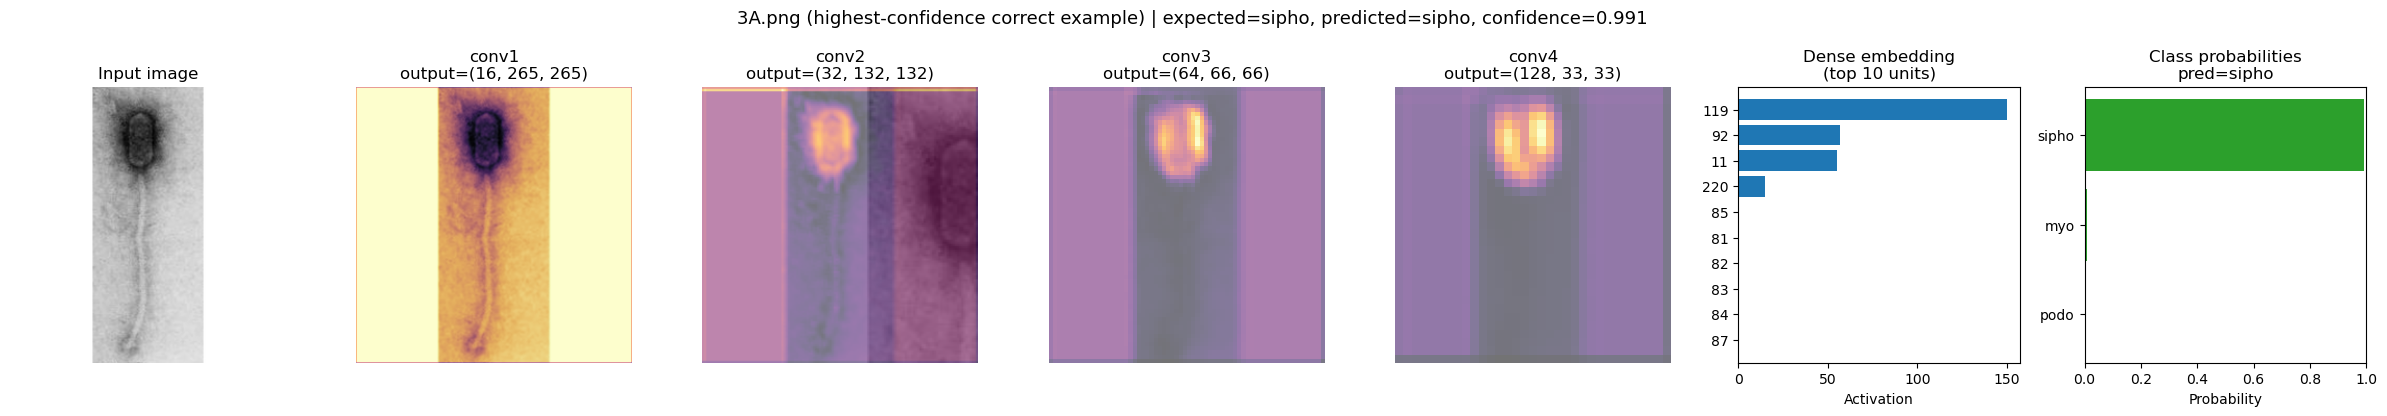

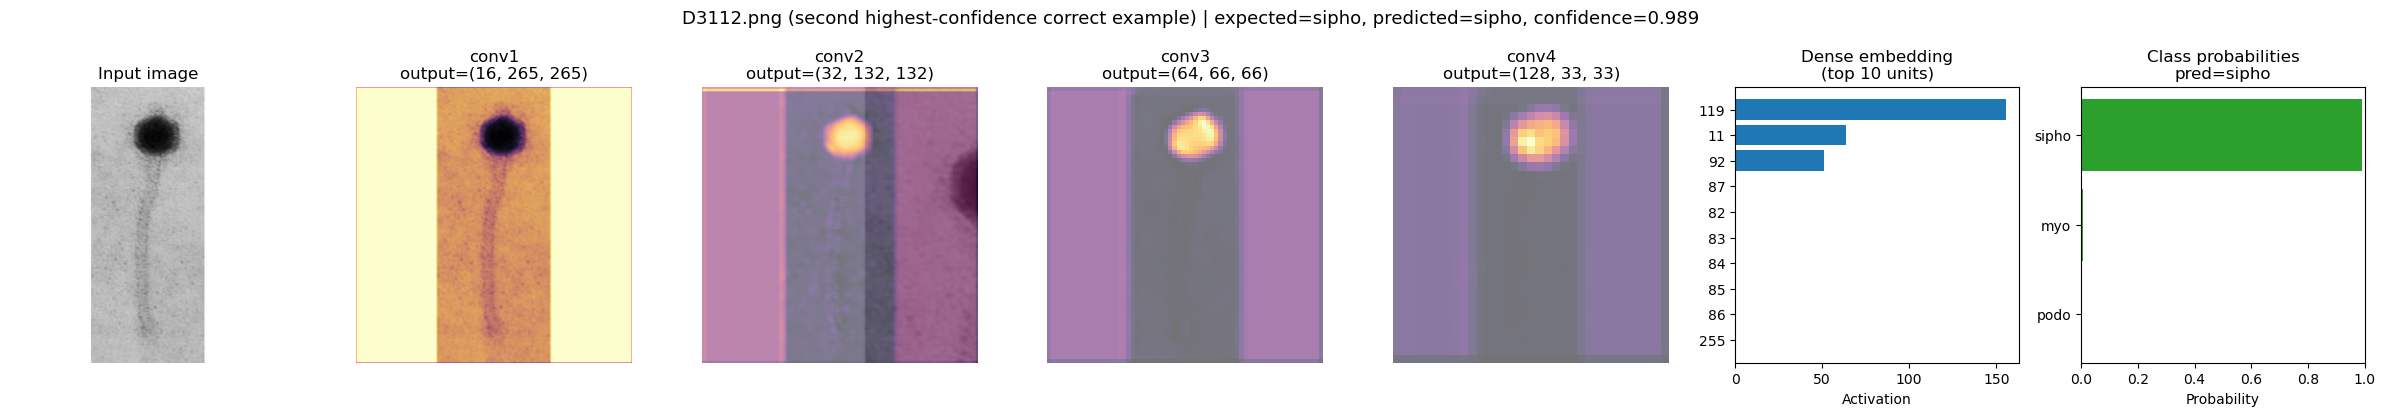

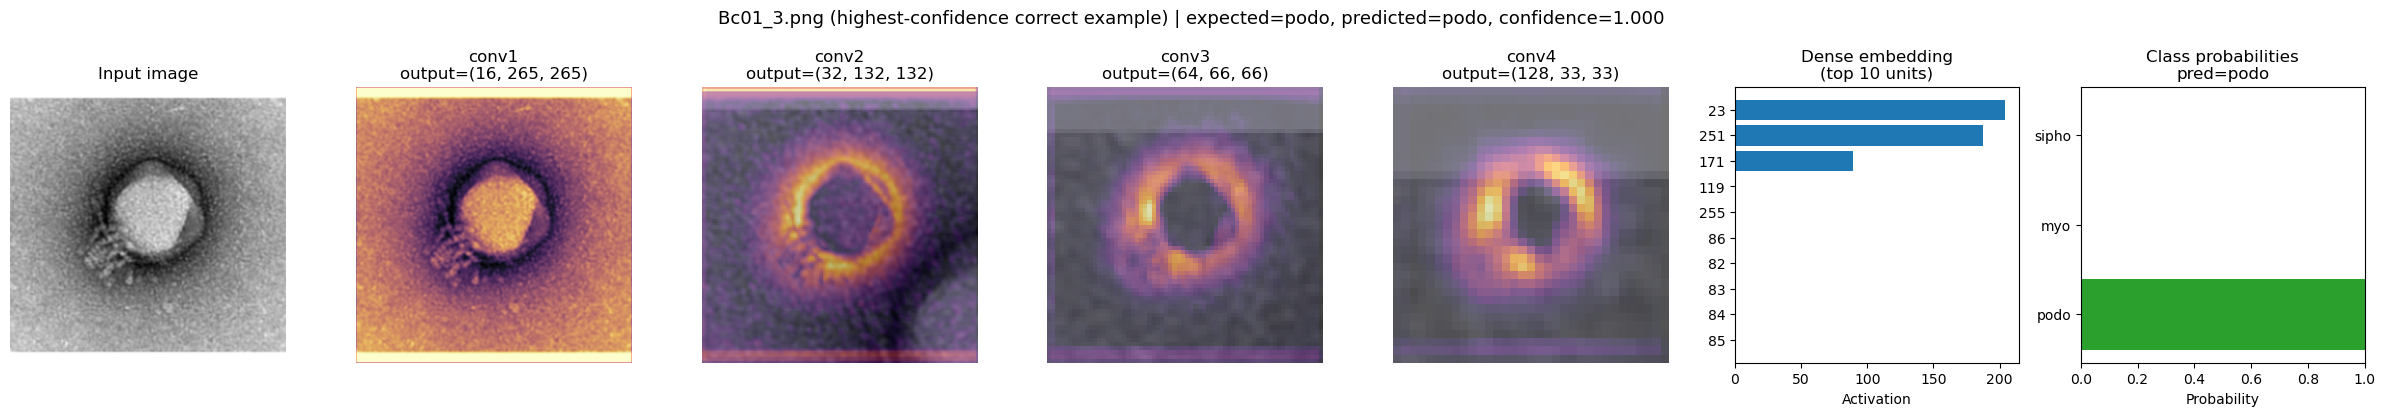

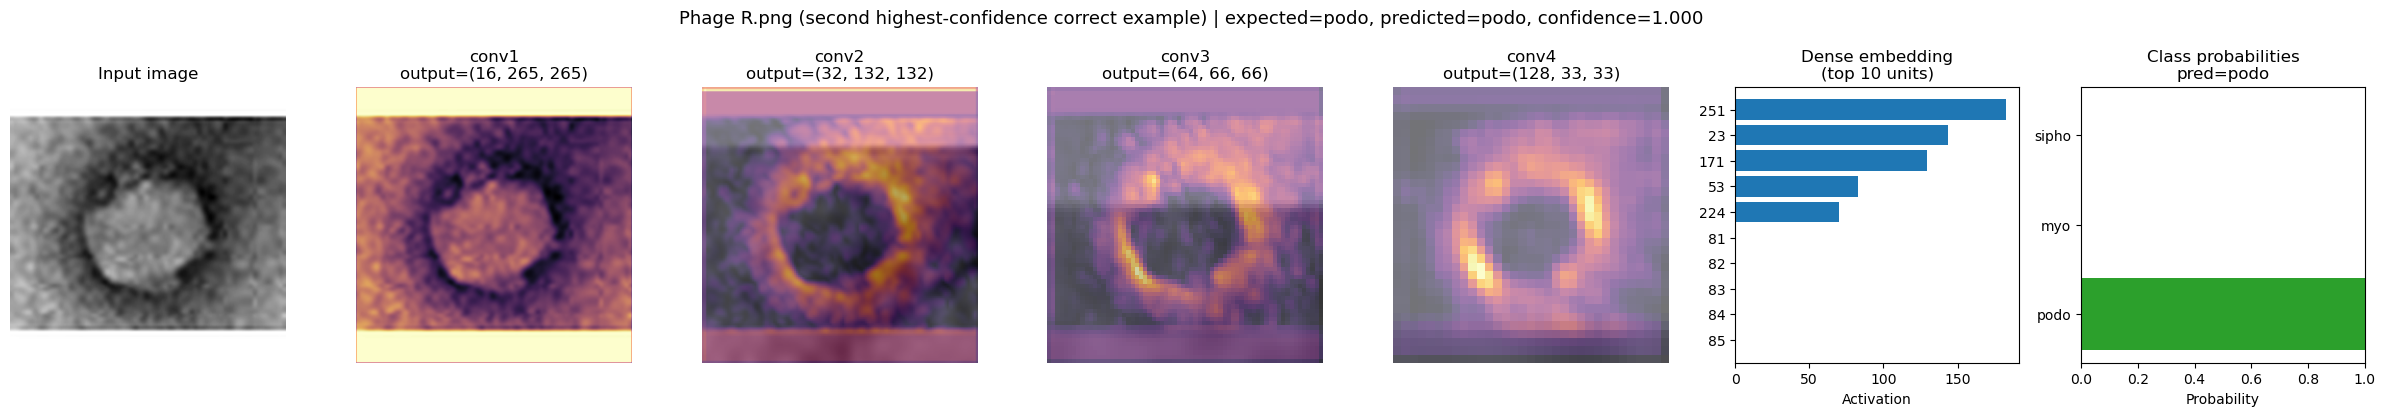

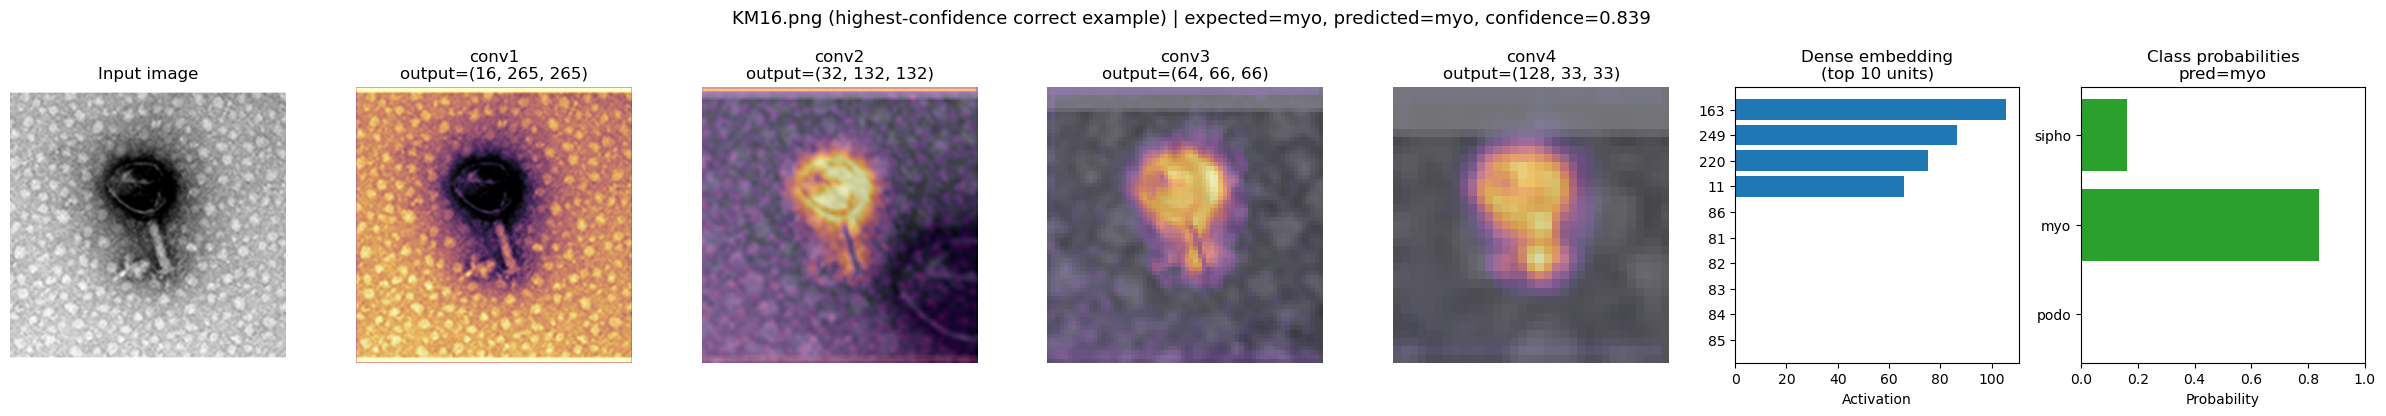

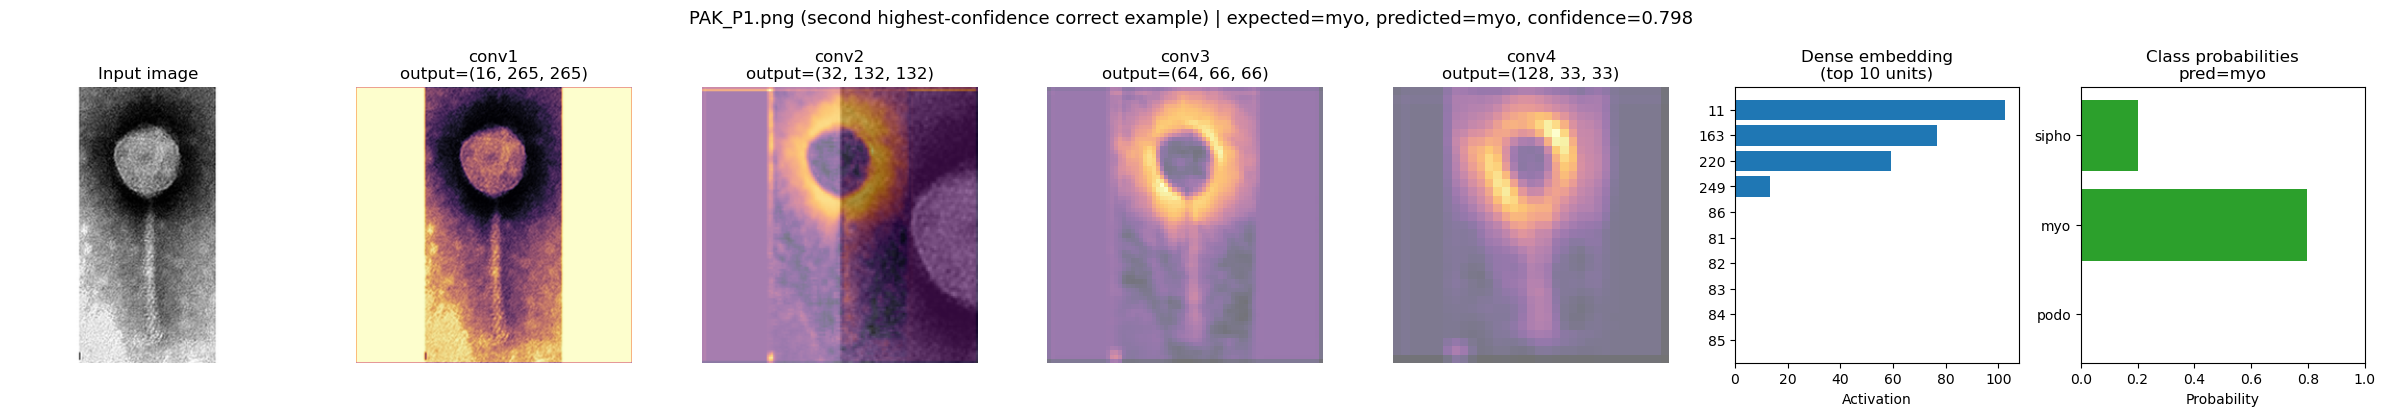

In [18]:
plot_first_layer_filters(model)

scored_test_df = score_dataframe(model, test_df)
representative_examples = select_representative_examples(scored_test_df, n_correct_examples=2)
display(
    representative_examples[
        ['label', 'pred_label', 'confidence', 'selection_rank', 'selection_note', 'filename']
    ].rename(columns={'label': 'true_label'})
)

for row in representative_examples.itertuples(index=False):
    explain_prediction_layers(
        image_path=row.processed_path,
        expected_label=row.label,
        title_prefix=f'{row.filename} ({row.selection_note})',
    )


## 11) Predict the morphotype of your own image

In [19]:

def load_trained_model(model_path=MODEL_PATH, device=DEVICE):
    checkpoint = torch.load(model_path, map_location=device)
    class_names_loaded = checkpoint['class_names']
    model_loaded = PhageMorphotypeCNN(num_classes=len(class_names_loaded)).to(device)
    model_loaded.load_state_dict(checkpoint['model_state_dict'])
    model_loaded.eval()
    return model_loaded, class_names_loaded


@torch.no_grad()
def predict_morphotype(image_path, model=None, class_names_local=None, device=DEVICE, show_image=True, show_explanations=False):
    """
    Predict morphotype for a single TEM image.

    Example:
        predict_morphotype('/path/to/my_image.png', show_explanations=True)
    """
    if model is None or class_names_local is None:
        model, class_names_local = load_trained_model()

    with Image.open(image_path) as im:
        processed = pad_to_square_and_resize(im, size=TARGET_SIZE)

    x = pil_to_tensor(processed).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_idx = int(np.argmax(probs))
    pred_label = class_names_local[pred_idx]

    result = pd.DataFrame({
        'class': class_names_local,
        'probability': probs
    }).sort_values('probability', ascending=False).reset_index(drop=True)

    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(processed, cmap='gray')
        plt.title(f'Predicted morphotype: {pred_label}')
        plt.axis('off')
        plt.show()

    if show_explanations:
        explain_prediction_layers(
            image_path,
            expected_label=None,
            title_prefix=Path(image_path).name,
            model_override=model,
            class_names_local=class_names_local,
        )

    return pred_label, result


In [20]:

# Example usage:
# Replace with your own image path
# my_image_path = '/mnt/data/my_new_tem_image.png'
# pred_label, pred_table = predict_morphotype(my_image_path, show_explanations=True)
# print('Predicted morphotype:', pred_label)
# display(pred_table)



## Notes

- The notebook uses **grayscale images** because TEM images are effectively intensity-based.
- Padding is applied before resizing so rectangular figures become square without distortion.
- The dataset is small, so ROC curves and accuracy can vary noticeably.
- Labels now come directly from the CSV, with a normalized filename fallback for duplicate-like suffixes such as `_2` or ` copy`.
- If you want, the next improvement would be to add cross-validation, class-balanced sampling, or a stronger CNN/transfer-learning model.
